In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models 

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
print("X-train shape: ", X_train.shape)
print("y-train shape: ", y_train.shape)
print("X-test shape: ", X_test.shape)
print("y-test shape: ", y_test.shape)


X-train shape:  (60000, 28, 28)
y-train shape:  (60000,)
X-test shape:  (10000, 28, 28)
y-test shape:  (10000,)


In [4]:
# normalize data
X_train = X_train /255.0
X_test= X_test /255.0

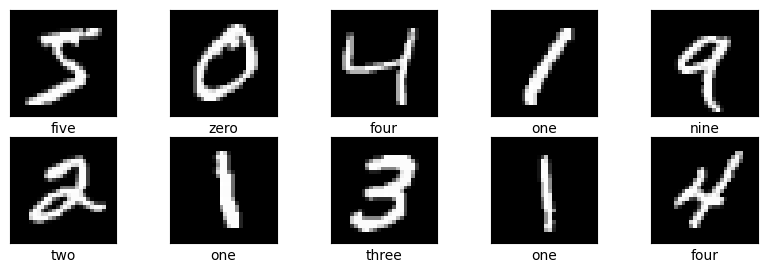

In [5]:
col_names= ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']

# visualize images

plt.figure(figsize=(10,8))
for i in range(len(np.unique(y_test))):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train[i], cmap='gray')
    plt.xlabel(col_names[y_train[i]])
plt.show()

In [6]:
# reshape data
X_train_res = X_train.reshape(-1, 28 * 28)
X_test_res = X_test.reshape(-1, 28 * 28)

In [7]:
# model creation
ann_model = models.Sequential(
    [
        layers.Input(shape=(784,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [8]:
# model compile

ann_model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [ ]:
ann_model.fit(
    X_train_res,
    y_train,
    epochs=10,
    validation_data=(X_test_res, y_test),
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 19ms/step - accuracy: 0.9370 - loss: 0.2142 - val_accuracy: 0.9702 - val_loss: 0.1019
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.9734 - loss: 0.0871 - val_accuracy: 0.9731 - val_loss: 0.0834
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9806 - loss: 0.0597 - val_accuracy: 0.9761 - val_loss: 0.0795
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9857 - loss: 0.0444 - val_accuracy: 0.9765 - val_loss: 0.0753
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9887 - loss: 0.0350 - val_accuracy: 0.9772 - val_loss: 0.0877
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9907 - loss: 0.0283 - val_accuracy: 0.9799 - val_loss: 0.0730
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9919 - loss: 0.0244 - val_accuracy: 0.9777 - val_loss: 0.0922
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9928 -

In [10]:
ann_model.save('ann_model.keras')

In [13]:
y_pred = ann_model.predict(X_test_res)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [17]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred.argmax(axis=1))
print("Confusion Matrix :\n", cm)
print("Classification Report :\n", classification_report(y_test, y_pred.argmax(axis=1)))

Confusion Matrix :
 [[ 968    1    1    0    1    1    4    2    2    0]
 [   0 1118    2    0    0    0    4    0   11    0]
 [   2    1 1009    4    2    0    2    4    8    0]
 [   0    0    6  987    0    5    0    4    8    0]
 [   2    0    2    0  950    2    9    5    4    8]
 [   2    0    0    5    1  868    5    1    9    1]
 [   2    2    0    0    2    2  945    0    5    0]
 [   0    2    9    4    0    0    0 1009    4    0]
 [   1    2    1    1    1    0    1    2  964    1]
 [   3    2    1   11   10    7    1   10   35  929]]
Classification Report :
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.97      0.97       982
           5       0.98      0.97      0.98       892
           6       0.97      0.99      0.98  

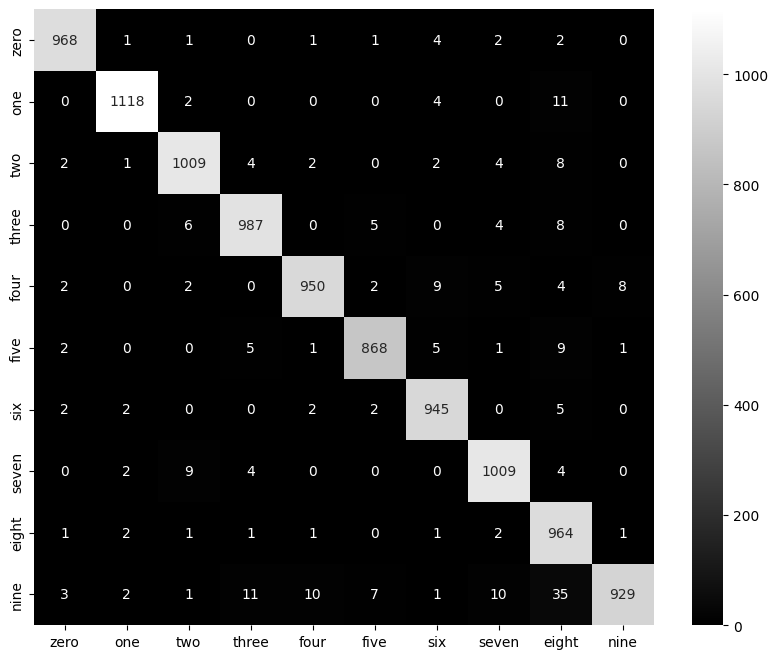

In [19]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, cmap="gray", fmt="d", xticklabels=col_names, yticklabels=col_names
)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
Predicted Digit: seven
Actual Digit: seven


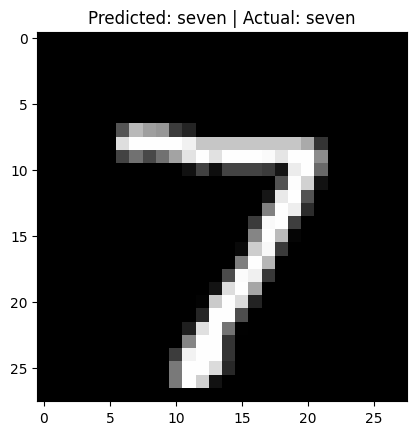

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predicted Digit: two
Actual Digit: two


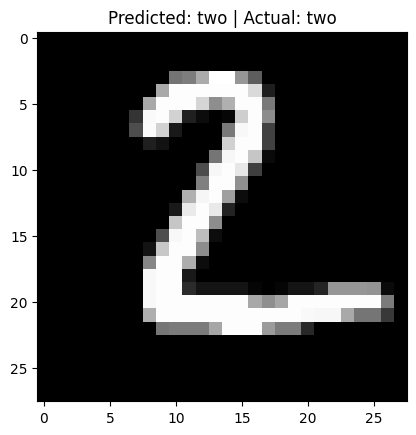

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
Predicted Digit: one
Actual Digit: one


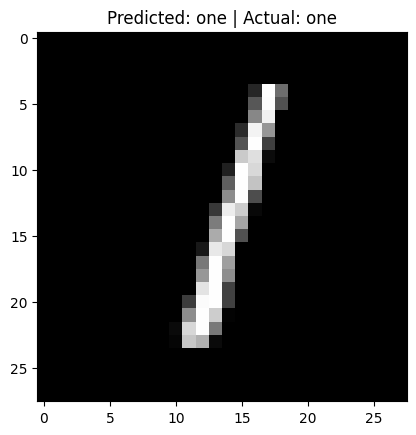

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Predicted Digit: zero
Actual Digit: zero


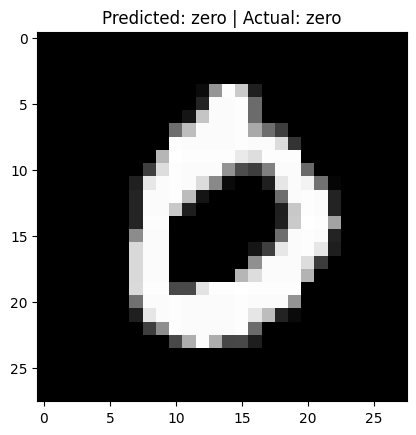

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
Predicted Digit: four
Actual Digit: four


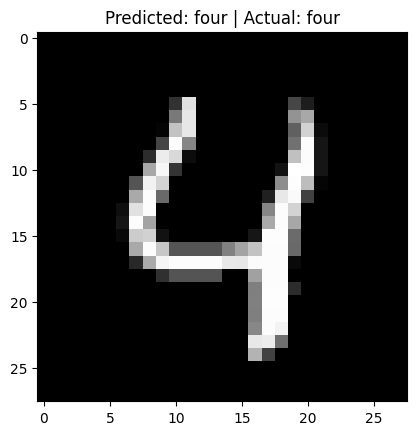

In [27]:
# deployment/ testing phase
saved_model = tf.keras.models.load_model("ann_model.keras")

(_, _), (X_test_dep, y_test_dep) = tf.keras.datasets.mnist.load_data()

for i in range(5):

    sample_image = X_test_dep[i]
    sample_label = y_test_dep[i]

    sample_image = sample_image.astype("float32") / 255.0
    sample_image_res = sample_image.reshape(1, 28 * 28)

    pred_prob = saved_model.predict(sample_image_res)
    pred_class = pred_prob.argmax(axis=1)[0]

    print(f"Predicted Digit: {col_names[pred_class]}")
    print(f"Actual Digit: {col_names[sample_label]}")

    # visualization
    plt.imshow(sample_image, cmap="gray")
    plt.title(f"Predicted: {col_names[pred_class]} | Actual: {col_names[sample_label]}")
    plt.show()